

=== Isolating the Perceptual Effect of Rate ===
Trial 0/1000...
Trial 100/1000...
Trial 200/1000...
Trial 300/1000...


/tmp/ipython-input-3513225957.py:141: RuntimeWarning: overflow encountered in exp
  val = 1 / (1 + np.exp(decay_rate * (t_elapsed - word_expected_duration / 2.5)))


Trial 400/1000...
Trial 500/1000...
Trial 600/1000...
Trial 700/1000...
Trial 800/1000...
Trial 900/1000...

PERCEPTION at SLOW r=4.0 (N=968) top 8:
  ['lei', 'sure', 'or', 'time']            |  433 |  44.7%
  ['lei', 'sure', 'time']                  |  167 |  17.3%
  ['lei', 'sure', 'or', 'time', 'or', 'time'] |   50 |   5.2%
  ['lei', 'sure', 'or']                    |   46 |   4.8%
  ['lei', 'sure', 'lei', 'sure', 'or', 'time'] |   39 |   4.0%
  ['lei', 'sure']                          |   38 |   3.9%
  ['lei', 'sure', 'or', 'time', 'sure', 'or', 'time'] |   24 |   2.5%
  ['lei', 'sure', 'or', 'sure', 'or', 'time'] |   22 |   2.3%
  -> 'or' present: 731/968 = 75.5%

PERCEPTION at FAST r=40.0 (N=968) top 8:
  ['lei', 'sure', 'or', 'time']            |  143 |  14.8%
  ['lei', 'sure', 'or', 'time', 'sure', 'or', 'time'] |   55 |   5.7%
  ['lei', 'sure', 'lei', 'sure', 'or', 'time'] |   51 |   5.3%
  ['lei', 'sure', 'or', 'lei', 'sure', 'or', 'time'] |   48 |   5.0%
  ['lei', 'sure', 't

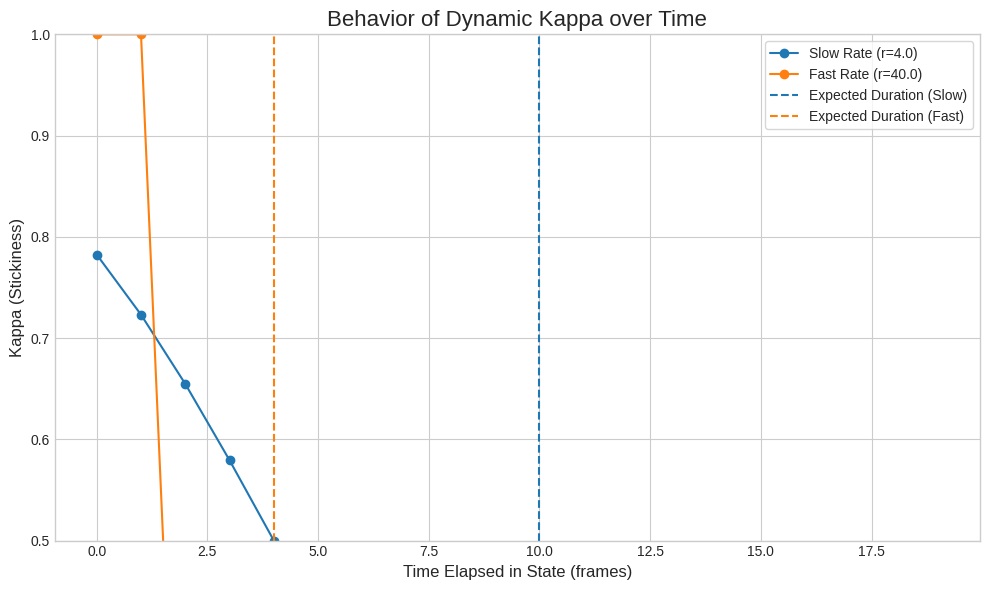



=== Generating Plot for Viterbi Paths ===


/tmp/ipython-input-3513225957.py:401: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


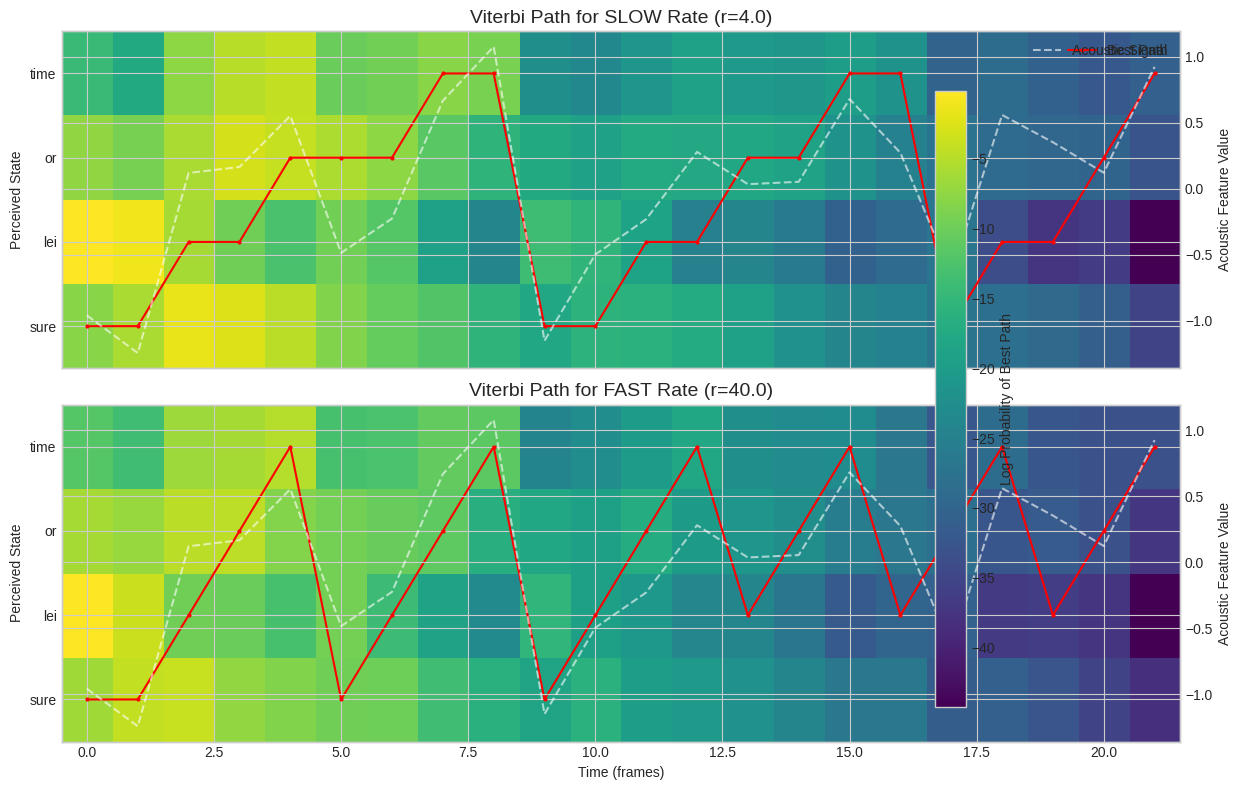

In [ ]:
import numpy as np
from collections import Counter
from scipy.stats import norm

np.random.seed(7)

# --------------
# States setup
# --------------
STATES = ["START", "lei", "sure", "or", "time", "STOP"] # All possible hidden states. The model must begin in the START state and eventually transition to the STOP state.
EMIT_STATES = {"lei", "sure", "or", "time"}  #This defines a subset of states that actually produce an emission, which is the observable acoustic signal. The START and STOP states are purely structural and don't correspond to any sound.
i = {s: k for k, s in enumerate(STATES)} # Create a convenient mapping from the state's name (e.g., "sure") to its numerical index in the STATES.

# ----------------
# Emissions setup
# ----------------
# 1D acoustic feature: 'lei' low, 'time' high, 'sure' and 'or' similar,  creating the acoustic ambiguity.
# This mirrors the real-world scenario where reduced function words blend in with the surrounding words.
mu = {
    "lei":  -1.0,
    "sure":  0.15,
    "or":    0.05,
    "time":  1.0
}
sigma = {s: 0.45 for s in EMIT_STATES}   # The amount of random noise or variability in the acoustic signal for each word, same for all states.


# ------------------------
# Base transitions (pi_bar) for the HMM, the default likelihood of moving from one word (state) to the next, independent of speech rate.
# ------------------------
# Construct and return a transition matrix, T. Each row in this matrix corresponds to a "from" state, and each column corresponds to a "to" state.
# The value at T[row, col] is the probability of transitioning from the row state to the col state.
def make_pi_bar(uniform_eps=0.0):
    n = len(STATES)
    T = np.zeros((n, n))
    def row_with_primary(from_s, primary):
        row = np.zeros(n)
        used = 0.0
        for to_s, w in primary.items():
            row[i[to_s]] += w
            used += w
        leftover = max(0.0, 1.0 - used)
        mask = np.ones(n, dtype=bool)
        for to_s in primary.keys():
            mask[i[to_s]] = False
        mask[i["START"]] = False
        if from_s == "STOP":
            mask[:] = False
            mask[i["STOP"]] = True
        count = mask.sum()
        if count > 0 and leftover > 0:
            row[mask] += leftover / count
        if uniform_eps > 0:
            row += uniform_eps
        row = row / row.sum()
        return row

    T[i["START"]] = row_with_primary("START", {"lei": 0.97})
    T[i["lei"]]   = row_with_primary("lei",   {"sure": 0.94})
    T[i["sure"]]  = row_with_primary("sure",  {"or": 0.55, "time": 0.40})
    T[i["or"]]    = row_with_primary("or",    {"time": 0.95})
    T[i["time"]]  = row_with_primary("time",  {"STOP": 0.96})
    T[i["STOP"]]  = row_with_primary("STOP",  {"STOP": 1.0})
    return T

pi_bar = make_pi_bar(uniform_eps=0.0)

# ------------------------
# Stickiness mapping kappa(gamma, rate)
# ------------------------
# Core theoretical mechanism: adjusting the HMM's transition probabilities based on speech rate.
def kappa_from_gamma_rate(gamma_val, rate, base=1.2, clip=(0.55, 0.93)):
    val = 1.0 - np.exp(-base * (gamma_val + 0.25) / (rate + 1e-9))
    return float(np.clip(val, clip[0], clip[1]))

def sample_gammas(seed=None):
    rng = np.random.default_rng(seed)
    g = {}
    for s in STATES:
        if s in {"START", "STOP"}: g[s] = 0.0
        else: g[s] = rng.gamma(shape=2.0, scale=1/5.0)
    return g

# Construct the final, rate-dependent transition matrix (T)
# Take the base transition probabilities (pi_bar) and modifies them using the calculated kappa.
def build_T(rate, gammas):
    n = len(STATES)
    T = np.zeros((n, n))
    for s_from in STATES:
        row = pi_bar[i[s_from]].copy()
        if s_from in {"START", "STOP"}:
            T[i[s_from]] = row
        else:
            kappa = kappa_from_gamma_rate(gammas[s_from], rate)
            row = (1 - kappa) * row
            row[i[s_from]] += kappa
            T[i[s_from]] = row / row.sum()
    return T

# ------------------------
# Generative process (Speaker)
# ------------------------
# This function simulates a "speaker" producing a single utterance based on the HMM rules.
# It generates both the sequence of hidden states (the words the speaker "thinks") and the observable acoustic signal that the listener would hear.
def simulate_one(rate, gammas, max_frames=1000, rng=None): # rate and gamma are the inputs that define the speaker's production style. The rate determines how "sticky" the states are.
    if rng is None: rng = np.random.default_rng()
    T = build_T(rate, gammas) # construct the final, rate-dependent transition matrix
    s = "START" # he simulation starts in the START
    states,emissions = [], []
    frame = 0
    while frame < max_frames: # enters a loop, generating one frame (a small slice of time) of the utterance at each iteration.
        s = rng.choice(STATES, p=T[i[s]]) # the core of the HMM simulation. It chooses the next state based on the probability distribution in the current state's row in the transition matrix T.
        if s == "STOP": break
        states.append(s)
        if s in EMIT_STATES:
            emissions.append(rng.normal(loc=mu[s], scale=sigma[s])) # generates an observable acoustic feature by drawing a random number from a normal (Gaussian) distribution
        frame += 1
    return states, np.array(emissions).reshape(-1, 1)
    # returns:
    # (1) The ground-truth sequence of hidden states (the words that were actually generated).
    # (2) The sequence of acoustic features that a listener would perceive.


# ------------------------
# Decoding process (Listener)
# ------------------------

# CORE IDEA: dynamic transition probabilities, they change at every single time step based on how long the listener has been "hearing" the current word.
# Unlike the simpler kappa used for the speaker, this one knows how long the listener has been "stuck" in the current state.

def dynamic_kappa_refined(t_elapsed, base_kappa, word_expected_duration, rate):
# t_elapsed: The number of time frames the decoder has spent in the current state.
# word_expected_duration: The typical length of the current word.
# Logic: The function uses a sigmoid (logistic) curve. kappa starts high, encouraging the listener to stay in the current state.
# As t_elapsed approaches the word's expected_duration, kappa drops sharply. This makes the listener feel an "urgency" to transition to a new word.
# The rate parameter controls how quickly this urgency builds up—a faster rate makes kappa drop sooner and more steeply.

    urgency_factor = (rate / 5.0)**2
    decay_rate = (5.0 / max(1.0, word_expected_duration)) * urgency_factor
    floor_kappa = base_kappa * 0.8
    val = 1 / (1 + np.exp(decay_rate * (t_elapsed - word_expected_duration / 2.5)))
    return val

# Build the log-transition matrix for a single moment in time
# For each state, it calculates the current kappa_t using dynamic_kappa_refined and the dwell_times.
# It then modifies the pi_bar (base transitions) with this new kappa_t to create the final transition matrix for that specific time step, t.
# This means the probability of transitioning out of a state increases the longer you've been in it.
def get_dynamic_logT(rate, gammas, dwell_times):
    n = len(STATES)
    logT = np.full((n, n), -np.inf)

    expected_durations = {}
    for s_from in STATES:
        if s_from in EMIT_STATES:
            base_kappa = kappa_from_gamma_rate(gammas[s_from], rate)
            expected_durations[s_from] = 1.0 / (1.0 - base_kappa) if (1.0 - base_kappa) > 0 else 1.0
        else:
            expected_durations[s_from] = 1.0

    for s_from_idx in range(n):
        s_from = STATES[s_from_idx]
        row = pi_bar[s_from_idx].copy()

        if s_from in {"START", "STOP"}:
            logT[s_from_idx, :] = np.log(row + 1e-12)
        else:
            t_elapsed = dwell_times[s_from_idx]
            base_kappa = kappa_from_gamma_rate(gammas[s_from], rate)
            kappa_t = dynamic_kappa_refined(t_elapsed, base_kappa, expected_durations[s_from], rate)

            row = (1 - kappa_t) * row
            row[s_from_idx] += kappa_t
            logT[s_from_idx, :] = np.log(row / row.sum() + 1e-12)

    return logT


# The main lister/decoder function.
# It takes the acoustic signal and figures out the most probable sequence of words that could have generated it.
## variable inferred by the viterbi algorithm/ selecting the most prob variable
def viterbi_decode_dynamic(a_data, rate, gammas):
# a_data: The sequence of observed acoustic features from the speaker.

    T_len = len(a_data)
    n = len(STATES)
    V = np.full((T_len, n), -np.inf) # (Viterbi Matrix): Stores the maximum probability of a path ending in a particular state at a particular time.
    B = np.zeros((T_len, n), dtype=int) #  (Backpointer Matrix): Stores the best previous state that leads to the maximum probability path at each step. This is used to reconstruct the final path.
    D = np.zeros((T_len, n), dtype=int) #  (Dwell Time Matrix): A custom addition for the dynamic model. It tracks how long each potential path has been dwelling in its current state.
    logE = emission_log_probs(a_data) # calculate the log-probability of observing each piece of acoustic data given each possible hidden state

    # This calculates the log-probabilities of transitioning from the START state to any other state.
    start_row = np.log(pi_bar[i["START"]] + 1e-12)
    for s_idx in range(n):
        if STATES[s_idx] in EMIT_STATES:
            V[0, s_idx] = start_row[s_idx] + logE[0, s_idx] # The initial probability is the chance of starting with that word (start_row) plus the chance of that word emitting the first acoustic signal (logE).
            D[0, s_idx] = 1 # The dwell time for any starting path is set to 1.

    # main loop that iterates through the acoustic signal from the second time step to the end.
    for t in range(1, T_len):
        # At each time step t, it first calculates a new, unique log-transition matrix (logT_t).
        logT_t = get_dynamic_logT(rate, gammas, D[t-1])
        # For the current state j, this is the most critical calculation. It finds the best possible path to get here by:
        # Taking the probabilities of the best paths at the previous time step (V[t-1, :]).
        # Adding the log-probabilities of transitioning from each of those previous states to the current state j (logT_t[:, j]).
        # np.argmax finds the index (best_prev_k) of the previous state that yields the highest total probability.
        for j in range(n):
            prev_path_probs = V[t-1, :] + logT_t[:, j]
            best_prev_k = np.argmax(prev_path_probs)

            V[t, j] = prev_path_probs[best_prev_k] + logE[t, j] # It stores this new maximum probability in the Viterbi matrix for the current time t and state j.
            B[t, j] = best_prev_k # It stores the index of that best previous state in the Backpointer matrix.

            if j == best_prev_k:
                D[t, j] = D[t-1, best_prev_k] + 1
            else:
                D[t, j] = 1
            # Update the Dwell time. If the best path was a self-loop (e.g., from "sure" to "sure"), it increments the dwell counter. If it was a transition from a different state, it resets the counter to 1.


   # Reconstructing the Path
    path = np.zeros(T_len, dtype=int)
    path[-1] = np.argmax(V[-1]) # The algorithm starts at the end. It finds the most likely state for the last time step by looking for the maximum probability in the last column of the V matrix.
    for t in range(T_len - 2, -1, -1): # It then works its way backward in time. At each step t, it looks up the best previous state in the Backpointer matrix (B) and adds it to the path.
        path[t] = B[t + 1, path[t + 1]] # Finally, it translates the sequence of state indices back into their readable string names ( [2, 2, 4] becomes ['sure', 'sure', 'time']) and returns this as the result.

    return [STATES[k] for k in path], V, path

# Helper function(pre-calculates the emission log-probabilities)
def emission_log_probs(a_data):
    T = len(a_data)
    n = len(STATES)
    logp = np.full((T, n), -np.inf)
    for t in range(T):
        for s in EMIT_STATES:
            logp[t, i[s]] = norm.logpdf(a_data[t, 0], loc=mu[s], scale=sigma[s])
    return logp

def compress(seq):
    return [s for idx, s in enumerate(seq) if idx == 0 or s != seq[idx-1]]

def summarize(name, seqs):
    c = Counter(tuple(s) for s in seqs)
    total = sum(c.values())
    print(f"\n{name} (N={total}) top 8:")
    for (s, cnt) in c.most_common(8):
        print(f"  {list(s)!s:<40} | {cnt:4d} | {100*cnt/total:5.1f}%")
    has_or = sum(1 for s in seqs if "or" in s)
    print(f"  -> 'or' present: {has_or}/{total} = {100*has_or/total:4.1f}%")



# =================================================================
# ISOLATING THE PERCEPTUAL EFFECT ==
# =================================================================
def run_isolated_perception_experiment(n_trials=1000, rate_slow=4.0, rate_fast=40.0):
    rng = np.random.default_rng(1234)
    gammas = sample_gammas(seed=2025)
    seq_slow_perception = []
    seq_fast_perception = []

    print("\n\n=== Isolating the Perceptual Effect of Rate ===")

    for k in range(n_trials):
        if k % 100 == 0: print(f"Trial {k}/{n_trials}...")

        # 1. Generate ONE ambiguous utterance at an intermediate rate.
        rate_generative = 5.5
        _, ambiguous_acoustic_signal = simulate_one(rate_generative, gammas, rng=rng)

        if len(ambiguous_acoustic_signal) < 3: continue

        # 2. Decode this SAME signal with a "slow-rate brain" model.
        #    CORRECTED LINE: Unpack the tuple and only keep the first item.
        zhat_slow, _, _ = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_slow, gammas)
        seq_slow_perception.append(compress(zhat_slow))

        # 3. Decode this SAME signal with a "fast-rate brain" model.
        #    CORRECTED LINE: Unpack the tuple here as well.
        zhat_fast, _, _ = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_fast, gammas)
        seq_fast_perception.append(compress(zhat_fast))

    # 4. Summarize and compare the perceptual results
    summarize(f"PERCEPTION at SLOW r={rate_slow}", seq_slow_perception)
    summarize(f"PERCEPTION at FAST r={rate_fast}", seq_fast_perception)


# =================================================================
# == PLOTTING THE DYNAMIC KAPPA CURVE ==
# =================================================================
import matplotlib.pyplot as plt

def plot_dynamic_kappa():
    print("\n\n=== Generating Plot for Dynamic Kappa ===")

    # 1. Define parameters for a typical, hypothetical word
    gamma_word = 0.4  # An intrinsic duration property for our example word
    word_expected_duration_slow = 10  # Expected duration in frames for slow speech
    word_expected_duration_fast = 4   # Expected duration in frames for fast speech

    # 2. Define slow and fast speech rates (can be the same as the experiment)
    rate_slow = 4.0
    rate_fast = 40.0

    # 3. Calculate the base kappa for both rates, needed by the dynamic function
    base_kappa_slow = kappa_from_gamma_rate(gamma_word, rate_slow)
    base_kappa_fast = kappa_from_gamma_rate(gamma_word, rate_fast)

    # 4. Create a range of time steps (t_elapsed) to plot
    t_elapsed_range = np.arange(0, 20, 1)

    # 5. Calculate the dynamic kappa value for each time step
    kappa_curve_slow = [dynamic_kappa_refined(t, base_kappa_slow, word_expected_duration_slow, rate_slow) for t in t_elapsed_range]
    kappa_curve_fast = [dynamic_kappa_refined(t, base_kappa_fast, word_expected_duration_fast, rate_fast) for t in t_elapsed_range]

    # --- Create the Plot ---

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(t_elapsed_range, kappa_curve_slow, marker='o', linestyle='-', label=f'Slow Rate (r={rate_slow})')
    ax.plot(t_elapsed_range, kappa_curve_fast, marker='o', linestyle='-', label=f'Fast Rate (r={rate_fast})')

    # Add vertical lines to indicate the expected durations for clarity
    ax.axvline(x=word_expected_duration_slow, color='C0', linestyle='--', label=f'Expected Duration (Slow)')
    ax.axvline(x=word_expected_duration_fast, color='C1', linestyle='--', label=f'Expected Duration (Fast)')

    # Add labels and a title
    ax.set_title('Behavior of Dynamic Kappa over Time', fontsize=16)
    ax.set_xlabel('Time Elapsed in State (frames)', fontsize=12)
    ax.set_ylabel('Kappa (Stickiness)', fontsize=12)
    ax.set_ylim(0.5, 1.0)
    ax.legend(frameon=True, loc='best')
    ax.grid(True)

    plt.tight_layout()
    plt.show()


# =================================================================
# == PLOTTING THE VITERBI PATHS ==
# =================================================================
def plot_viterbi_paths():
    print("\n\n=== Generating Plot for Viterbi Paths ===")

    # --- 1. Generate one clear example ---
    rng = np.random.default_rng(123) # Use a specific seed for a good example
    gammas = sample_gammas(seed=2025)
    rate_slow = 4.0
    rate_fast = 40.0
    rate_generative = 5.5

    # Keep generating signals until we get one of a reasonable length
    while True:
        _, ambiguous_acoustic_signal = simulate_one(rate_generative, gammas, rng=rng)
        if 20 < len(ambiguous_acoustic_signal) < 40:
            break

    # --- 2. Decode the signal under both conditions ---
    # We need the V matrix and the integer path for plotting
    _, V_slow, path_slow = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_slow, gammas)
    _, V_fast, path_fast = viterbi_decode_dynamic(ambiguous_acoustic_signal, rate_fast, gammas)

    # --- 3. Create the Plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    emit_state_indices = [i[s] for s in EMIT_STATES]
    emit_state_names = [s for s in EMIT_STATES]

    # Plot for SLOW rate
    # Heatmap of the Viterbi log-probabilities
    im1 = ax1.imshow(V_slow[:, emit_state_indices].T, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    ax1.plot(path_slow - 1, 'r-', marker='.', markersize=4, label='Best Path') # Subtract 1 to align with emit_state_indices
    ax1.set_title(f'Viterbi Path for SLOW Rate (r={rate_slow})', fontsize=14)
    ax1.set_yticks(range(len(emit_state_names)))
    ax1.set_yticklabels(emit_state_names)
    ax1.set_ylabel('Perceived State')
    ax1.legend()

    # Overlay the acoustic signal
    ax1_twin = ax1.twinx()
    ax1_twin.plot(ambiguous_acoustic_signal, 'w--', alpha=0.6, label='Acoustic Signal')
    ax1_twin.set_ylabel('Acoustic Feature Value')
    ax1_twin.legend(loc='upper right')

    # Plot for FAST rate
    # Heatmap of the Viterbi log-probabilities
    im2 = ax2.imshow(V_fast[:, emit_state_indices].T, aspect='auto', origin='lower', cmap='viridis', interpolation='nearest')
    ax2.plot(path_fast - 1, 'r-', marker='.', markersize=4, label='Best Path')
    ax2.set_title(f'Viterbi Path for FAST Rate (r={rate_fast})', fontsize=14)
    ax2.set_yticks(range(len(emit_state_names)))
    ax2.set_yticklabels(emit_state_names)
    ax2.set_xlabel('Time (frames)')
    ax2.set_ylabel('Perceived State')

    # Overlay the acoustic signal
    ax2_twin = ax2.twinx()
    ax2_twin.plot(ambiguous_acoustic_signal, 'w--', alpha=0.6, label='Acoustic Signal')
    ax2_twin.set_ylabel('Acoustic Feature Value')

    fig.colorbar(im1, ax=[ax1, ax2], orientation='vertical', label='Log Probability of Best Path')
    plt.tight_layout()
    plt.show()


run_isolated_perception_experiment(n_trials=1000)
plot_dynamic_kappa()
plot_viterbi_paths()



=== Generating Plot for Dynamic Kappa ===


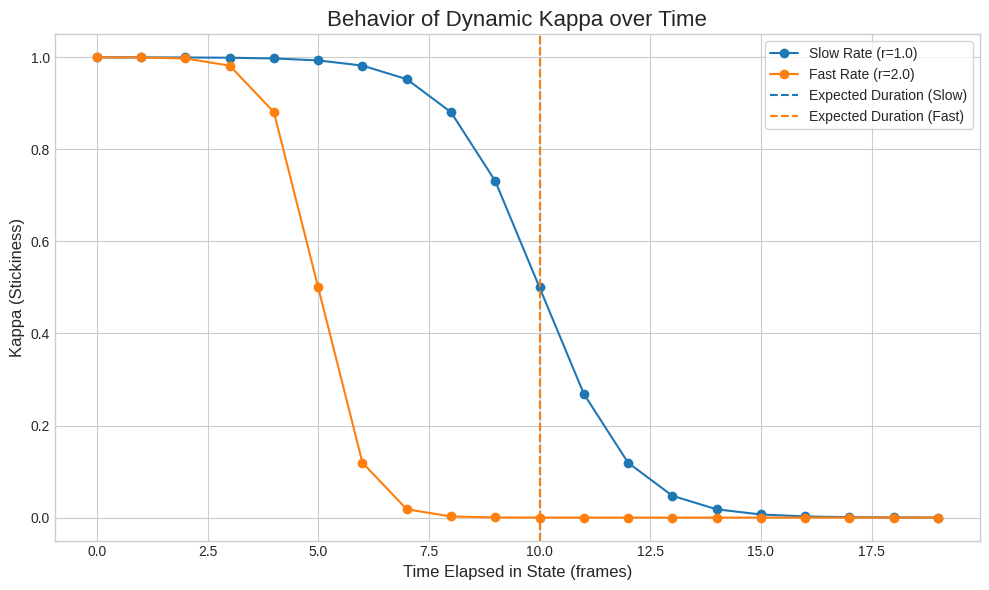

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dynamic_kappa_refined(t_elapsed, base_kappa, word_expected_duration, rate):
# t_elapsed: The number of time frames the decoder has spent in the current state.
# word_expected_duration: The typical length of the current word.
# Logic: The function uses a sigmoid (logistic) curve. kappa starts high, encouraging the listener to stay in the current state.
# As t_elapsed approaches the word's expected_duration, kappa drops sharply. This makes the listener feel an "urgency" to transition to a new word.
# The rate parameter controls how quickly this urgency builds up—a faster rate makes kappa drop sooner and more steeply.

    # make it depends on 200ms

    #urgency_factor = (rate / 5.0)**2
    #decay_rate = (5.0 / max(1.0, word_expected_duration)) * urgency_factor
    #floor_kappa = 0.5
    #val = floor_kappa + (0.99 - floor_kappa) / (1 + np.exp(decay_rate * (t_elapsed - word_expected_duration / 2.5)))
    val = 1 / (1 + np.exp(-word_expected_duration + rate*t_elapsed))
    return val

def plot_dynamic_kappa():
    print("\n\n=== Generating Plot for Dynamic Kappa ===")

    # 1. Define parameters for a typical, hypothetical word
    gamma_word = 0.4  # An intrinsic duration property for our example word
    word_expected_duration_slow = 10  # Expected duration in frames for slow speech
    word_expected_duration_fast = 10   # Expected duration in frames for fast speech

    # 2. Define slow and fast speech rates (can be the same as the experiment)
    rate_slow = 1.0
    rate_fast = 2.0

    # 3. Calculate the base kappa for both rates, needed by the dynamic function
    base_kappa_slow = 200 #kappa_from_gamma_rate(gamma_word, rate_slow)
    base_kappa_fast = 200 #kappa_from_gamma_rate(gamma_word, rate_fast)

    # 4. Create a range of time steps (t_elapsed) to plot
    t_elapsed_range = np.arange(0, 20, 1)

    # 5. Calculate the dynamic kappa value for each time step
    kappa_curve_slow = [dynamic_kappa_refined(t, base_kappa_slow, word_expected_duration_slow, rate_slow) for t in t_elapsed_range]
    kappa_curve_fast = [dynamic_kappa_refined(t, base_kappa_fast, word_expected_duration_fast, rate_fast) for t in t_elapsed_range]

    # --- Create the Plot ---

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(t_elapsed_range, kappa_curve_slow, marker='o', linestyle='-', label=f'Slow Rate (r={rate_slow})')
    ax.plot(t_elapsed_range, kappa_curve_fast, marker='o', linestyle='-', label=f'Fast Rate (r={rate_fast})')

    # Add vertical lines to indicate the expected durations for clarity
    ax.axvline(x=word_expected_duration_slow, color='C0', linestyle='--', label=f'Expected Duration (Slow)')
    ax.axvline(x=word_expected_duration_fast, color='C1', linestyle='--', label=f'Expected Duration (Fast)')

    # Add labels and a title
    ax.set_title('Behavior of Dynamic Kappa over Time', fontsize=16)
    ax.set_xlabel('Time Elapsed in State (frames)', fontsize=12)
    ax.set_ylabel('Kappa (Stickiness)', fontsize=12)
    #ax.set_ylim(0.5, 1.0)
    ax.legend(frameon=True, loc='best')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_dynamic_kappa()

bump function--